Importing the dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans


Data Collection & Analysis

In [2]:
# loading the data from csv file to a Pandas DataFrame
data = pd.read_csv('/content/Mall_Customers.csv')

In [3]:
# first 5 rows in the dataframe
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# finding the number of rows and columns
data.shape

(200, 5)

In [5]:
# getting some informations about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
# checking for missing values
data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


Exploratory Data Analysis

<Axes: xlabel='count', ylabel='Gender'>

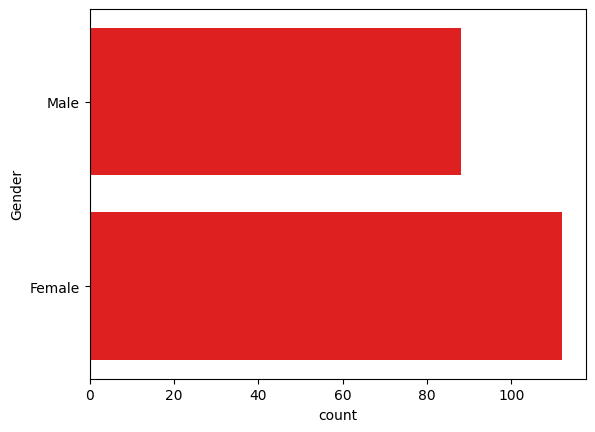

In [7]:
sns.countplot(data['Gender'] , color='red')

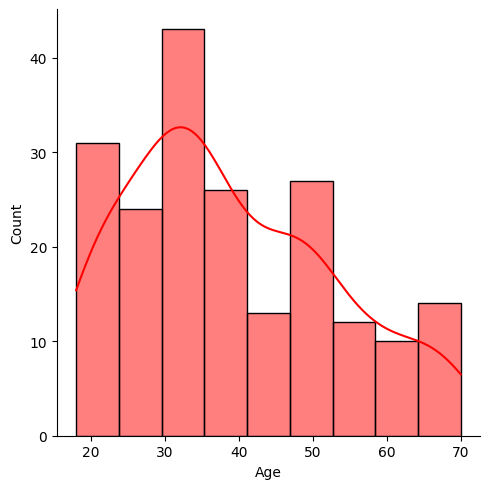

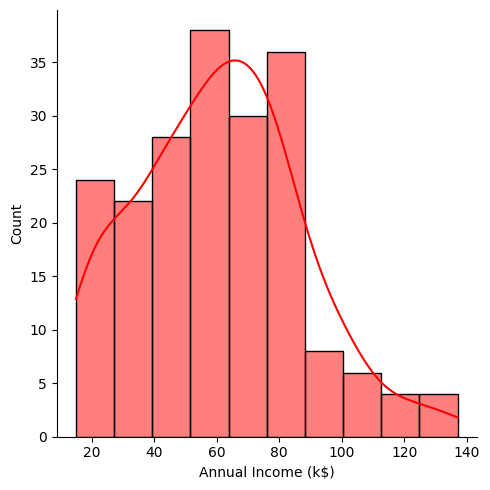

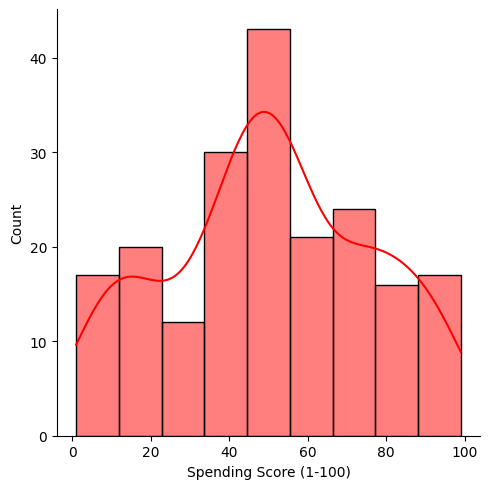

In [8]:
#plot histogram
cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for col in cols:
    sns.displot(data[col] , color = 'red' , kde=True)

<Axes: >

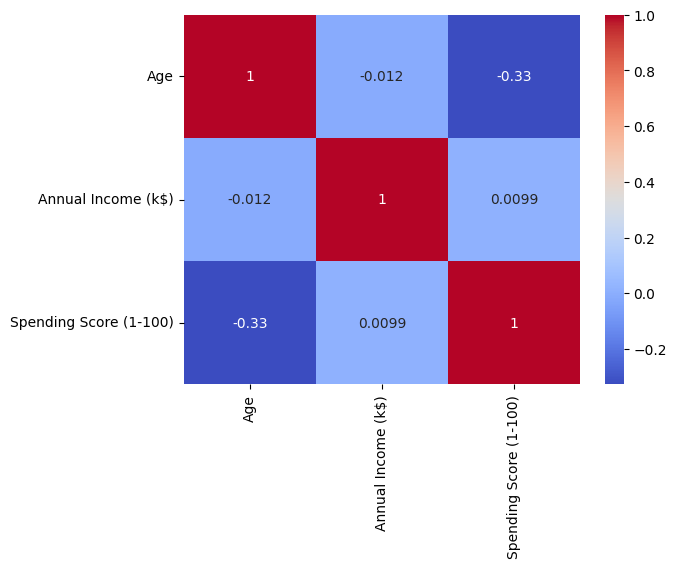

In [9]:
corr = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr()
sns.heatmap(corr, annot=True , cmap='coolwarm')

Kmeans Clustering (2 Features)

In [10]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

In [11]:
from sklearn.cluster import KMeans

In [12]:
wcss = []
for i in range(1,11):
    k_means = KMeans(n_clusters=i)
    k_means.fit(X)
    wcss.append(k_means.inertia_)

In [13]:
wcss

[269981.28000000014,
 186362.95600651755,
 132154.04264069264,
 73880.64496247198,
 44448.45544793369,
 40845.0821432953,
 37537.190442890445,
 25315.541822712155,
 27927.624097563195,
 20561.011843329077]

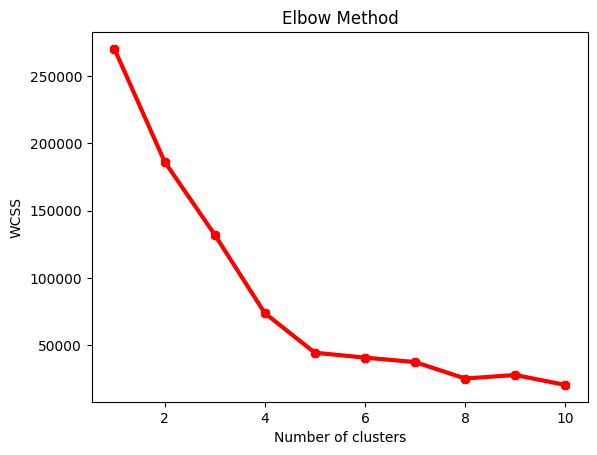

In [14]:
plt.plot(range(1,11), wcss , linewidth=3 , color='red' , marker='8')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

**5 is the Best Value for k**

In [15]:
k_means = KMeans(n_clusters=5 , random_state =42)
y_means = k_means.fit_predict(X)

In [16]:
y_means

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

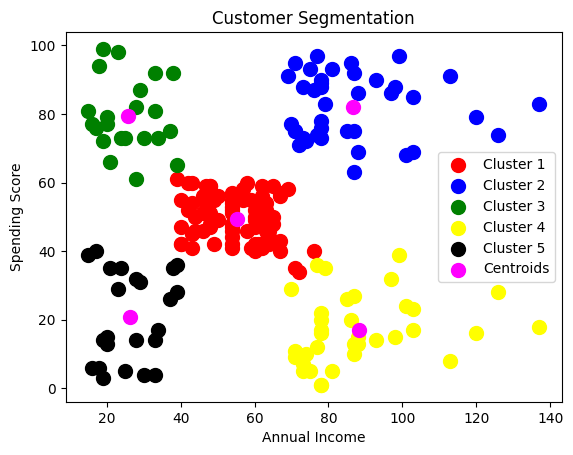

In [17]:
plt.scatter(X.iloc[y_means == 0 , 0] ,  X.iloc[y_means == 0 , 1] , s = 100 , c='red' , label='Cluster 1')
plt.scatter(X.iloc[y_means == 1 , 0] ,  X.iloc[y_means == 1 , 1] , s = 100 , c='blue' , label='Cluster 2')
plt.scatter(X.iloc[y_means == 2 , 0] ,  X.iloc[y_means == 2 , 1] , s = 100 , c='green' , label='Cluster 3')
plt.scatter(X.iloc[y_means == 3 , 0] ,  X.iloc[y_means == 3 , 1] , s = 100 , c='yellow' , label='Cluster 4')
plt.scatter(X.iloc[y_means == 4 , 0] ,  X.iloc[y_means == 4, 1] , s = 100 , c='black' , label='Cluster 5')
plt.scatter(k_means.cluster_centers_[:,0] , k_means.cluster_centers_[:,1] , s = 100 , c='magenta' , label='Centroids')
plt.title('Customer Segmentation')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

In [18]:
k_means.predict([[10,15]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([4], dtype=int32)

In [19]:
import pickle

In [20]:
pickle.dump(k_means , open('k_means.pkl' , 'wb'))